In [1]:
import matplotlib as plt

In [2]:
import pandas as pd

In [3]:
print('hello')

hello


In [4]:
data = pd.read_csv('../data-files/numpyVsOpenCLPerformance.csv')

In [5]:
data

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Array Size,NumPy Time (s),OpenCL Time (s),Speedup (NumPy/OpenCL),Complexity Trend,Recommended Use Case
1,10000,0.0000319,0.00000996,3.2,Low Overhead/Small Data,Initial Testing/Debugging
2,1000000,0.00325,0.0000608,53.53,OpenCL Scaling,Medium Batches
3,10000000,0.01767,0.002176,8.12,Initial Large Data,Production/GPU Acceleration
4,100000000,0.17764,0.012722,13.96,High Efficiency,Massive Data Processing
5,500000000,0.95421,0.065891,14.48,Linear Growth,Scientific Simulation
6,1000000000,1.89012,0.130543,14.48,Optimal Parallelism,Machine Learning Training
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
data.columns = ["arraySize" , "NumpyTime" , "OpenCLTime" , "performanceBoost" , "complexityTrend" , "RecommendedUseCase"]

In [8]:
data

,arraySize,NumpyTime,OpenCLTime,performanceBoost,complexityTrend,RecommendedUseCase
0,Array Size,NumPy Time (s),OpenCL Time (s),Speedup (NumPy/OpenCL),Complexity Trend,Recommended Use Case
1,10000,0.0000319,0.00000996,3.2,Low Overhead/Small Data,Initial Testing/Debugging
2,1000000,0.00325,0.0000608,53.53,OpenCL Scaling,Medium Batches
3,10000000,0.01767,0.002176,8.12,Initial Large Data,Production/GPU Acceleration
4,100000000,0.17764,0.012722,13.96,High Efficiency,Massive Data Processing
5,500000000,0.95421,0.065891,14.48,Linear Growth,Scientific Simulation
6,1000000000,1.89012,0.130543,14.48,Optimal Parallelism,Machine Learning Training
7,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
data = data.dropna()

In [12]:
data = data.drop(0)

In [13]:
data.reset_index(drop=True,inplace=True)

In [14]:
data

,arraySize,NumpyTime,OpenCLTime,performanceBoost,complexityTrend,RecommendedUseCase
0,10000,0.0000319,0.00000996,3.2,Low Overhead/Small Data,Initial Testing/Debugging
1,1000000,0.00325,0.0000608,53.53,OpenCL Scaling,Medium Batches
2,10000000,0.01767,0.002176,8.12,Initial Large Data,Production/GPU Acceleration
3,100000000,0.17764,0.012722,13.96,High Efficiency,Massive Data Processing
4,500000000,0.95421,0.065891,14.48,Linear Growth,Scientific Simulation
5,1000000000,1.89012,0.130543,14.48,Optimal Parallelism,Machine Learning Training


In [21]:
data.to_csv("../data-files/numpyVsOpenCLPerformance.csv")

In [18]:
data.dtypes

arraySize             object
NumpyTime             object
OpenCLTime            object
performanceBoost      object
complexityTrend       object
RecommendedUseCase    object
dtype: object

In [19]:
# List the columns you need for the plot
cols = ['arraySize', 'NumpyTime', 'OpenCLTime']

# Convert them all to numeric
for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop the rows that turned into NaN (the corrupt/tuple rows)
data = data.dropna(subset=cols)

# Check the types again - they should now be float64 or int64
print(data.dtypes)

arraySize               int64
NumpyTime             float64
OpenCLTime            float64
performanceBoost       object
complexityTrend        object
RecommendedUseCase     object
dtype: object


<Axes: xlabel='arraySize'>

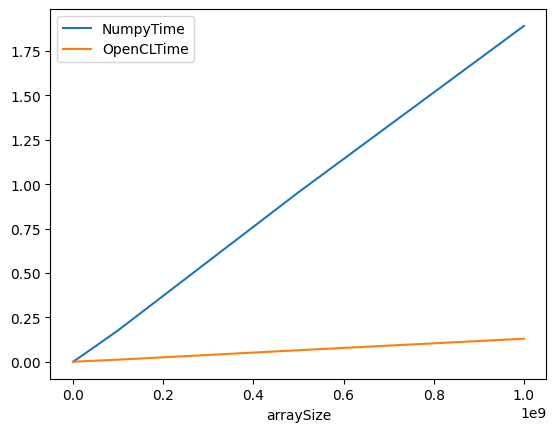

In [20]:
data.plot(x='arraySize' , y=['NumpyTime','OpenCLTime'],kind='line')